## Failure Analysis - Where Does the Pipeline Break and Can We Fix It?

### Background
After encoding a total of 4000 images between the CASIA & IITD datasets, we were able to create a preliminary dataset consisting of failed images. The goal is to investigate these errors to identify bottlenecks and improve the overall success of the pipeline

### 1. Setup & Imports

The following libraries are used throughout this analysis:

- **`iris`** — Worldcoin's open-source Iris Recognition Inference System (IRIS), which provides the full biometric pipeline: segmentation, normalization, feature extraction, and matching.
- **`cv2` (OpenCV)** — for image I/O and preprocessing operations such as inpainting, CLAHE, and edge detection.
- **`pandas` / `numpy`** — for data manipulation and numerical computation.
- **`sklearn`** — for the failure prediction model (Random Forest classifier, pipeline utilities, and evaluation metrics).
- **`matplotlib`** — for visualizing images and results.


In [1]:
import pandas as pd
import numpy as np
import os
import ast
import cv2
import iris
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support

### 2. Loading the Dataset

We load the pre-built failure dataset, which was generated by running the IRIS pipeline over 4,000 images from the **CASIA** and **IITD** iris databases.

Each row records:
| Column | Description |
|---|---|
| `dataset` | Source dataset (CASIA or IITD) |
| `subject_id` | Subject identifier |
| `eye` | Left eye, right eye, or unknown |
| `image_path` | Path to the source image |
| `success` | 1 = pipeline succeeded, 0 = failure |
| `error` | Error type and details when `success == 0` |


In [2]:
full_df = pd.read_csv("failure_dataset (1).csv")

print("Total rows:", len(full_df))
print(full_df["success"].value_counts())

Total rows: 4000
1    3183
0     817
Name: success, dtype: int64


### 3. Filtering Invalid Inputs

The raw dataset includes images from a normalized sub-directory (`Normalized_Images`) that were not valid raw iris inputs for the pipeline. We remove these to obtain a clean baseline of genuine failures.

In [3]:
df_base = full_df[~full_df["image_path"].str.contains("Normalized_Images", na=False)].copy()

print("Rows after removing Normalized_Images:", len(df_base))
print(df_base["success"].value_counts())

Rows after removing Normalized_Images: 3333
1    3183
0     150
Name: success, dtype: int64


### 4. Isolating Failures & Parsing Error Types

We filter to only failed images and extract the `error_type` field from the structured error string. This lets us understand which stage of the IRIS pipeline is responsible for each failure.

The IRIS pipeline stages where errors can originate include:
1. **Segmentation** — detecting iris boundaries and eye geometry
2. **Normalization** — unrolling the iris into a rectangular representation
3. **Vectorization** — encoding the normalized iris into a bitstring (iris code)
4. **Matching** — comparing iris codes


In [4]:
failed_df = df_base[df_base["success"] == 0].copy()

failed_df["error_type"] = failed_df["error"].astype(str).str.extract(r"'error_type': '([^']+)'")

print("Number of failures:", len(failed_df))
print(failed_df["error_type"].value_counts(dropna=False))

Number of failures: 150
VectorizationError               134
EyeOrientationEstimationError     10
OcclusionError                     3
MaskTooSmallError                  1
EyeCentersEstimationError          1
SharpnessEstimationError           1
Name: error_type, dtype: int64


### 5. Vectorization Error Investigation

`VectorizationError` is the most common error type in the dataset. We run the IRIS pipeline on a representative failing image to examine what metadata is returned and identify where the actual breakdown occurs.

The `iris.IRISPipeline` is initialized once and reused across all runs. Each image is passed as an `iris.IRImage` object with the raw grayscale pixel data, a unique image ID, and the eye side (left/right).

In [5]:
pipeline = iris.IRISPipeline()

test_row = failed_df[failed_df["error_type"] == "VectorizationError"].iloc[0]

img_path = test_row["image_path"]
eye_side = "left" if str(test_row["eye"]).upper().endswith("L") else "right"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

result = pipeline(
    iris.IRImage(
        img_data=img,
        image_id=os.path.basename(img_path),
        eye_side=eye_side,))

print(result)

{'error': {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/co

the pipeline never got a usable iris/eye geometry before vectorization. So the vectorization error is mostly a downstream symptom of segmentation failure.

### 5.1 Visualizing the Failing Image

We display the image that triggered the `VectorizationError` to visually diagnose the problem.


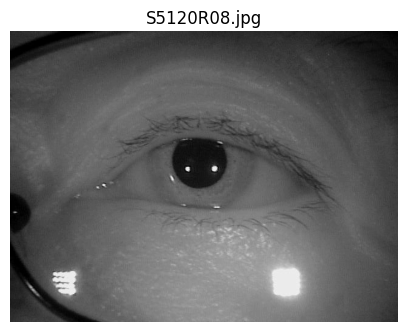

shape: (480, 640)


In [6]:
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(os.path.basename(img_path))
plt.axis("off")
plt.show()

print("shape:", img.shape)

Bright reflections at the bottom from glasses glare

The glare is likely:
- breaking the iris boundary
- creating multiple contours

this causes:
“Number of contours must be equal to 1"

### 5.2 Preprocessing Attempt 1: Glare Inpainting

Visual inspection reveals bright reflections (likely from glasses) at the bottom of the image. These break the iris boundary, causing the segmentation stage to fail.

We attempt to remove glare by:
1. Thresholding pixels above intensity 220 to create a glare mask
2. Dilating the mask to capture surrounding contamination
3. Using OpenCV's Telea inpainting algorithm to fill the masked region


In [7]:
def preprocess_glare_simple(img):
    mask = (img > 220).astype("uint8") * 255
    
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    
    return cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

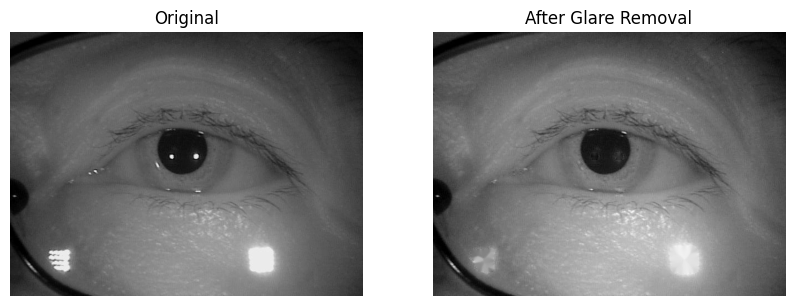

In [8]:
processed = preprocess_glare_simple(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(processed, cmap='gray')
plt.title("After Glare Removal")
plt.axis('off')

plt.show()

In [9]:
result2 = pipeline(iris.IRImage(img_data=processed,image_id=os.path.basename(img_path),eye_side=eye_side,))
print(result2)

{'error': {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/co

### 5.3 Preprocessing Attempt 2:  Bottom Crop

Since the glare is concentrated at the bottom of the image, we try cropping the bottom 18% and resizing back to the original dimensions. This removes the glare region entirely before passing the image to the pipeline.


In [10]:
def crop_bottom_glare(img, crop_ratio=0.18):
    h, w = img.shape
    cropped = img[:int(h * (1 - crop_ratio)), :]
    return cv2.resize(cropped, (w, h))

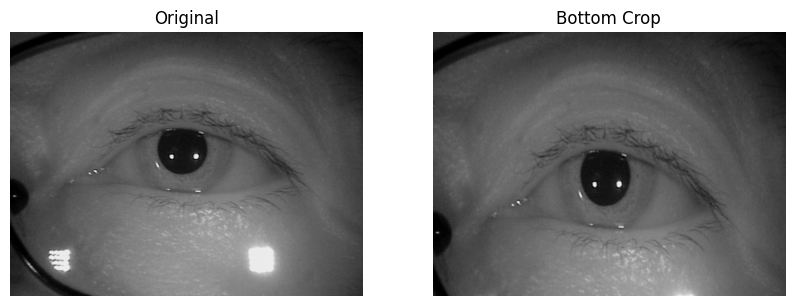

In [11]:
processed2 = crop_bottom_glare(img, crop_ratio=0.18)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(processed2, cmap='gray')
plt.title("Bottom Crop")
plt.axis('off')

plt.show()

In [12]:
result3 = pipeline(iris.IRImage(img_data=processed2,image_id=os.path.basename(img_path),eye_side=eye_side,))
print(result3)

{'error': {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/co

### 5.4 Preprocessing Attempt 3: CLAHE Contrast Enhancement

CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances local contrast in the image, which can improve the segmentation model's ability to detect iris boundaries in low-contrast or unevenly lit images.


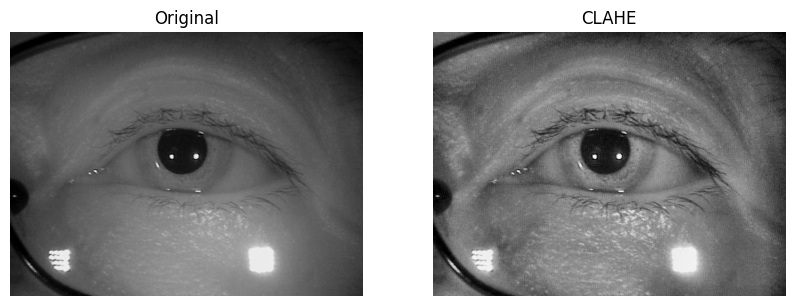

In [13]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
processed3 = clahe.apply(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(processed3, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

plt.show()

In [14]:
result4 = pipeline(iris.IRImage(img_data=processed3,image_id=os.path.basename(img_path),eye_side=eye_side,))
print(result4)

{'error': {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/co

From this image we tried:
- glare removal
- bottom crop
- CLAHE

and the result was still the same:

VectorizationError
eye_centers = None
iris_bbox = None

So for images like this, the evidence points to the segmentation stage is the bottleneck, not simple preprocessing

### 6. Broadening the VectorizationError Sample

Having diagnosed a single image, we now sample 5 images with `VectorizationError` and run the pipeline on each, checking whether `eye_centers` and `iris_bbox` are populated in the returned metadata. If both are `None`, the failure is upstream of vectorization.



Image 1: S5694R07.jpg
error: {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/no

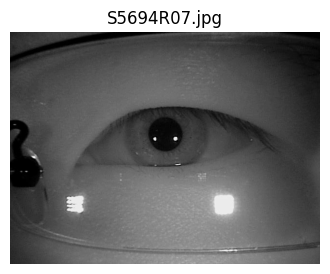


Image 2: S5329R08.jpg
error: {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/no

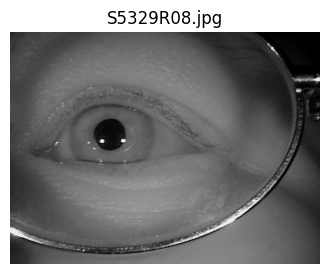


Image 3: S5544R04.jpg
error: {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/no

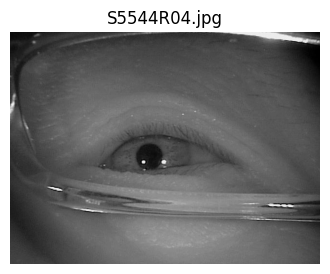


Image 4: S5605R09.jpg
error: {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/no

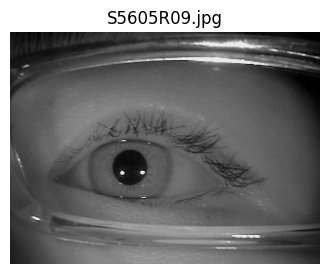


Image 5: S5185L04.jpg
error: {'error_type': 'VectorizationError', 'message': '_find_class_contours: Number of contours must be equal to 1.', 'traceback': '  File "/Users/morganfox/Desktop/open-iris/src/iris/pipelines/base_pipeline.py", line 108, in run\n    _ = self.nodes[node.name](**input_kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 70, in __call__\n    return self.execute(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/io/class_configs.py", line 81, in execute\n    result = self.run(*args, **kwargs)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 75, in run\n    geometry_contours = self._find_contours(geometry_mask)\n  File "/Users/morganfox/Desktop/open-iris/src/iris/nodes/vectorization/contouring.py", line 88, in _find_contours\n    eyeball_array = self._find_class_contours(mask.filled_eyeball_mask.astype(np.uint8))\n  File "/Users/morganfox/Desktop/open-iris/src/iris/no

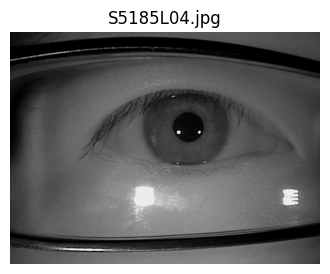

In [15]:
sample_df = failed_df[failed_df["error_type"] == "VectorizationError"].sample(5, random_state=42)

for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    img_path = row["image_path"]
    eye_side = "left" if str(row["eye"]).upper().endswith("L") else "right"

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    result = pipeline(iris.IRImage(img_data=img,image_id=os.path.basename(img_path),eye_side=eye_side,))

    meta = result.get("metadata", {}) if isinstance(result, dict) else {}

    print(f"\nImage {i}: {os.path.basename(img_path)}")
    print("error:", result.get("error", None))
    print("eye_centers:", meta.get("eye_centers"))
    print("iris_bbox:", meta.get("iris_bbox"))

    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()

upstream segmentation failures
because the images repeatedly return:

eye_centers = None
iris_bbox = None

So the pipeline never gets usable eye geometry before vectorization even starts.

### 7. Quantifying Segmentation Failures Across All VectorizationErrors

We iterate over all `VectorizationError` images and check whether their pipeline outputs contain valid segmentation metadata. This lets us measure what fraction of `VectorizationError` cases are actually caused by upstream segmentation failures.


In [16]:
vec_df = failed_df[failed_df["error_type"] == "VectorizationError"].copy()

seg_fail_count = 0
records = []

for _, row in vec_df.iterrows():
    img_path = row["image_path"]
    eye_side = "left" if str(row["eye"]).upper().endswith("L") else "right"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    result = pipeline(iris.IRImage(img_data=img,image_id=os.path.basename(img_path),eye_side=eye_side,))

    meta = result.get("metadata", {}) if isinstance(result, dict) else {}
    eye_centers = meta.get("eye_centers")
    iris_bbox = meta.get("iris_bbox")

    seg_failed = (eye_centers is None) or (iris_bbox is None)

    if seg_failed:
        seg_fail_count += 1

    records.append({
        "image_path": img_path,
        "eye_centers": eye_centers,
        "iris_bbox": iris_bbox,
        "segmentation_failed": seg_failed})

seg_check_df = pd.DataFrame(records)

print("Vectorization failures checked:", len(vec_df))
print("Likely upstream segmentation failures:", seg_fail_count)
print("Percent:", round(100 * seg_fail_count / len(vec_df), 2), "%")

Vectorization failures checked: 134
Likely upstream segmentation failures: 134
Percent: 100.0 %


### 8. Building a Segmentation Failure Predictor

Rather than running the full IRIS pipeline on every image (which is compute-intensive), we build a lightweight classifier that predicts pipeline failure from simple image quality metrics.

### 8.1 Feature Engineering

We compute the following per-image statistics using OpenCV:

| Feature | Description |
|---|---|
| `brightness` | Mean pixel intensity |
| `contrast` | Standard deviation of pixel intensities |
| `blur_score` | Variance of the Laplacian (sharpness proxy) |
| `edge_density` | Fraction of pixels classified as edges by Canny |
| `dark_pixel_ratio` | Fraction of pixels with intensity < 40 |
| `bright_pixel_ratio` | Fraction of pixels with intensity > 220 (glare proxy) |
| `height`, `width` | Image dimensions |

These features capture the primary image quality dimensions that are likely to affect iris segmentation performance.


In [17]:
def compute_image_metrics(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return {
            "read_error": True,
            "brightness": np.nan,
            "contrast": np.nan,
            "blur_score": np.nan,
            "edge_density": np.nan,
            "dark_pixel_ratio": np.nan,
            "bright_pixel_ratio": np.nan,
            "height": np.nan,
            "width": np.nan,
        }

    brightness = float(np.mean(img))
    contrast = float(np.std(img))
    blur_score = float(cv2.Laplacian(img, cv2.CV_64F).var())
    edges = cv2.Canny(img, 100, 200)
    edge_density = float(np.mean(edges > 0))
    dark_pixel_ratio = float(np.mean(img < 40))
    bright_pixel_ratio = float(np.mean(img > 220))
    h, w = img.shape

    return {
        "read_error": False,
        "brightness": brightness,
        "contrast": contrast,
        "blur_score": blur_score,
        "edge_density": edge_density,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "height": h,
        "width": w,
    }

model_df = full_df[~full_df["image_path"].str.contains("Normalized_Images", na=False)].copy()

model_df["segmentation_failed"] = (model_df["success"] == 0).astype(int)

metrics_df = pd.DataFrame(model_df["image_path"].apply(compute_image_metrics).tolist())
model_df = pd.concat([model_df.reset_index(drop=True), metrics_df], axis=1)

feature_cols = ["brightness","contrast","blur_score","edge_density","dark_pixel_ratio",
                "bright_pixel_ratio","height","width",]

X = model_df[feature_cols]
y = model_df["segmentation_failed"]

print("Rows:", len(model_df))
print("Failures:", y.sum())
print("Successes:", (y == 0).sum())
model_df.head()

Rows: 3333
Failures: 150
Successes: 3183


,dataset,subject_id,eye,image_path,success,error,segmentation_failed,read_error,brightness,contrast,blur_score,edge_density,dark_pixel_ratio,bright_pixel_ratio,height,width
0,CASIA,191,L,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/191/...,1,NaN,0,False,85.347227,35.381282,149.786119,0.012933,0.110166,0.000221,480,640
1,CASIA,194,R,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/194/...,1,NaN,0,False,89.221403,37.317928,155.712780,0.012132,0.093577,0.004687,480,640
2,CASIA,398,L,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/398/...,1,NaN,0,False,83.184600,46.428852,145.971606,0.022158,0.158822,0.040957,480,640
3,CASIA,429,R,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/429/...,1,NaN,0,False,93.728633,33.178146,83.648777,0.005924,0.055879,0.000319,480,640
4,CASIA,562,R,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/562/...,1,NaN,0,False,84.945654,31.267965,65.706233,0.003031,0.054971,0.000371,480,640


### 8.2 Training the Failure Prediction Model

We train a **Random Forest classifier** to predict whether a given image will fail the IRIS pipeline. The model is wrapped in a sklearn `Pipeline` with a `SimpleImputer` to handle any missing values from unreadable images.

We use an 80/20 train-test split with stratification to preserve the class imbalance ratio.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[632   5]
 [ 25   5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       637
           1       0.50      0.17      0.25        30

    accuracy                           0.96       667
   macro avg       0.73      0.58      0.61       667
weighted avg       0.94      0.96      0.94       667

ROC AUC: 0.8996336996336998


### 8.3 Addressing Class Imbalance

Since failures are a minority class, the default model may over-predict success. We retrain with `class_weight="balanced"` to up-weight failure examples during training.


In [19]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"))])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[632   5]
 [ 26   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       637
           1       0.44      0.13      0.21        30

    accuracy                           0.95       667
   macro avg       0.70      0.56      0.59       667
weighted avg       0.94      0.95      0.94       667

ROC AUC: 0.8512820512820514


### 8.4 Threshold Tuning

The model outputs a failure probability. By lowering the decision threshold from the default 0.5, we can increase recall (catching more true failures at the cost of more false positives). We sweep across thresholds to understand the precision-recall trade-off.

In [20]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')

    print(f"\nThreshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")


Threshold: 0.5
Precision: 0.444
Recall:    0.133
F1 Score:  0.205

Threshold: 0.4
Precision: 0.250
Recall:    0.167
F1 Score:  0.200

Threshold: 0.3
Precision: 0.226
Recall:    0.233
F1 Score:  0.230

Threshold: 0.2
Precision: 0.255
Recall:    0.400
F1 Score:  0.312

Threshold: 0.1
Precision: 0.227
Recall:    0.567
F1 Score:  0.324


### 8.5 Prediction Function

We wrap the model into a reusable function that accepts pre-computed image metrics and a configurable threshold, returning both a binary prediction and the raw failure probability.


In [46]:
def predict_segmentation_failure(model, img_metrics, threshold=0.1):
    prob = model.predict_proba(img_metrics)[0, 1]
    return prob >= threshold, prob

In [47]:
sample_test = failed_df.sample(5, random_state=42)

for _, row in sample_test.iterrows():
    img_path = row["image_path"]

    metrics = compute_image_metrics(img_path)
    metrics_df = pd.DataFrame([metrics])[feature_cols]

    will_fail, prob = predict_segmentation_failure(model, metrics_df, threshold=0.1)

    print(f"{os.path.basename(img_path)} → Fail? {will_fail} (prob={prob:.2f})")

S5089L06.jpg → Fail? True (prob=0.79)
S5086R03.jpg → Fail? True (prob=0.66)
S5271R06.jpg → Fail? True (prob=0.78)
S5374R07.jpg → Fail? True (prob=0.56)
S5352R07.jpg → Fail? True (prob=0.76)


### 9. Adaptive Pipeline: Screen Then Process

We integrate the failure predictor into a two-stage screening workflow:

1. **Compute image quality metrics** cheaply before running the full IRIS pipeline.
2. **Predict failure probability** using the trained classifier.
3. **Skip** images predicted to fail (above threshold), avoiding wasted computation.
4. **Run the IRIS pipeline** only on images predicted to succeed.

This reduces unnecessary processing while maintaining pipeline throughput on high-quality images.


In [48]:
screen_results = []

sample_test = failed_df.sample(20, random_state=42)

for _, row in sample_test.iterrows():
    img_path = row["image_path"]
    eye_side = "left" if str(row["eye"]).upper().endswith("L") else "right"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    metrics = compute_image_metrics(img_path)
    metrics_df = pd.DataFrame([metrics])[feature_cols]

    will_fail, prob = predict_segmentation_failure(model, metrics_df, threshold=0.1)

    if will_fail:
        outcome = "skipped_predicted_failure"
    else:
        result = pipeline(iris.IRImage(img_data=img,image_id=os.path.basename(img_path),eye_side=eye_side,))
        outcome = "ran_pipeline"

    screen_results.append({
        "image_path": img_path,
        "predicted_failure": will_fail,
        "failure_probability": prob,
        "outcome": outcome})

screen_results_df = pd.DataFrame(screen_results)
screen_results_df

,image_path,predicted_failure,failure_probability,outcome
0,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/089/...,True,0.79,skipped_predicted_failure
1,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/086/...,True,0.66,skipped_predicted_failure
2,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/271/...,True,0.78,skipped_predicted_failure
3,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/374/...,True,0.56,skipped_predicted_failure
4,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/352/...,True,0.76,skipped_predicted_failure
5,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/710/...,True,0.86,skipped_predicted_failure
6,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/932/...,True,0.74,skipped_predicted_failure
7,./IITD_database/118/04_L.bmp,True,0.63,skipped_predicted_failure
8,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/329/...,True,0.76,skipped_predicted_failure
9,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/664/...,True,0.78,skipped_predicted_failure


In [49]:
screen_results_df["outcome"].value_counts()

skipped_predicted_failure    18
ran_pipeline                  2
Name: outcome, dtype: int64

### 9.1 False Positive Check on Mixed Data

We apply the failure predictor to a balanced sample of both successes and failures to measure the false positive rate — i.e., how often the screener incorrectly flags a valid image as likely to fail, skipping it unnecessarily.


In [50]:
mixed_sample = df_base.sample(20, random_state=42).copy()

mixed_results = []

for _, row in mixed_sample.iterrows():
    img_path = row["image_path"]

    metrics = compute_image_metrics(img_path)
    metrics_df = pd.DataFrame([metrics])[feature_cols]

    will_fail, prob = predict_segmentation_failure(model, metrics_df, threshold=0.1)

    mixed_results.append({
        "image_path": img_path,
        "actual_success": row["success"],
        "predicted_failure": will_fail,
        "failure_probability": prob})

mixed_results_df = pd.DataFrame(mixed_results)
mixed_results_df

,image_path,actual_success,predicted_failure,failure_probability
0,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/315/...,1,False,0.00
1,./IITD_database/032/05_L.bmp,1,False,0.00
2,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/440/...,1,False,0.00
3,./IITD_database/164/02_L.bmp,1,False,0.00
4,./IITD_database/175/08_R.bmp,1,False,0.00
5,./IITD_database/124/01_L.bmp,1,False,0.00
6,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/084/...,1,True,0.16
7,./CASIA-Iris-Thousand/CASIA-Iris-Thousand/358/...,1,False,0.00
8,./IITD_database/188/09_R.bmp,1,False,0.00
9,./IITD_database/184/10_R.bmp,1,False,0.00


In [51]:
mixed_results_df["predicted_failure"].value_counts()

False    19
True      1
Name: predicted_failure, dtype: int64

In [52]:
false_positive_rate = (mixed_results_df["predicted_failure"] & (mixed_results_df["actual_success"] == 1)).mean()
print("False positive rate:", false_positive_rate)

False positive rate: 0.05


### 10. Pipeline Failure Summary Visualization

We visualize the cascade of failure reduction: starting from all cleaned failures, down to vectorization-labeled failures, and confirming that all of them are caused by upstream segmentation failures.


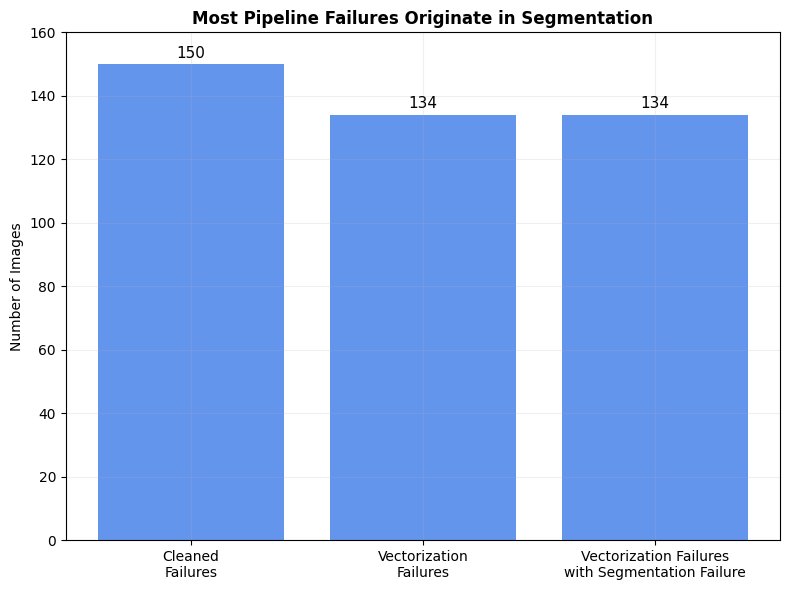

In [53]:
labels = ["Cleaned\nFailures","Vectorization\nFailures","Vectorization Failures\nwith Segmentation Failure"]
values = [150, 134, 134]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color="cornflowerblue")

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,val + 2,str(val),ha='center', fontsize=11 )

plt.ylabel("Number of Images")
plt.title("Most Pipeline Failures Originate in Segmentation", weight='bold')
plt.ylim(0, 160)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

After removing invalid normalized inputs, most remaining failures were labeled as vectorization errors. Further inspection showed that 100% of these cases lacked valid segmentation outputs, indicating that segmentation is the true bottleneck.

### 11. Preprocessing Fallback System

Since segmentation is the true bottleneck, we implement a systematic fallback strategy that tries multiple preprocessing variants in sequence. If any variant yields valid segmentation outputs (`eye_centers` and `iris_bbox` both non-None), we accept that result and move on.

### Preprocessing Variants Defined

| Variant | Description |
|---|---|
| `original` | No preprocessing — raw image |
| `clahe` | Adaptive histogram equalization |
| `gamma` | Gamma correction (brightens dark images) |
| `glare_mask` | Inpaint bright pixels above threshold 220 |
| `bottom_crop` | Crop and resize to remove bottom 18% |
| `combo` | Glare mask followed by CLAHE |


In [54]:
def seg_preprocess_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

def seg_preprocess_gamma(img, gamma=1.25):
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(img, table)

def seg_preprocess_glare_mask(img):
    mask = (img > 220).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.dilate(mask, kernel, iterations=1)
    return cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

def seg_preprocess_bottom_crop(img, crop_ratio=0.18):
    h, w = img.shape
    cropped = img[:int(h * (1 - crop_ratio)), :]
    return cv2.resize(cropped, (w, h))

def seg_preprocess_combo(img):
    out = seg_preprocess_glare_mask(img)
    out = seg_preprocess_clahe(out)
    return out

SEGMENTATION_VARIANTS = {
    "original": lambda x: x,
    "clahe": seg_preprocess_clahe,
    "gamma": seg_preprocess_gamma,
    "glare_mask": seg_preprocess_glare_mask,
    "bottom_crop": seg_preprocess_bottom_crop,
    "combo": seg_preprocess_combo,}

def segmentation_ok(result):
    if not isinstance(result, dict):
        return False
    meta = result.get("metadata", {})
    return (meta.get("eye_centers") is not None) and (meta.get("iris_bbox") is not None)

def run_pipeline_with_segmentation_fallbacks(img_path, eye_side, pipeline):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, "read_error", None

    for name, fn in SEGMENTATION_VARIANTS.items():
        proc = fn(img)

        result = pipeline(iris.IRImage(img_data=proc,image_id=os.path.basename(img_path),eye_side=eye_side,))

        if segmentation_ok(result):
            return result, name, proc

    return result, "failed_all_variants", img

In [59]:
def apply_preprocess_variant(img, variant):
    if variant in SEGMENTATION_VARIANTS:
        return SEGMENTATION_VARIANTS[variant](img)
    return img 

### 11.1 Fallback Pipeline on Sample Images

We run the full fallback pipeline on a 10-image sample of `VectorizationError` cases and report which preprocessing variant (if any) recovered a valid segmentation result.


In [60]:
sample_vec = failed_df[failed_df["error_type"] == "VectorizationError"].sample(10, random_state=42)

for _, row in sample_vec.iterrows():
    img_path = row["image_path"]
    eye_side = "left" if str(row["eye"]).upper().endswith("L") else "right"

    result, variant_used, proc = run_pipeline_with_segmentation_fallbacks(img_path, eye_side, pipeline)

    print(os.path.basename(img_path), "->", variant_used)
    if isinstance(result, dict):
        print(result.get("metadata", {}))

S5694R07.jpg -> failed_all_variants
{'iris_version': '1.10.0', 'image_id': 'S5694R07.jpg', 'image_size': (640, 480), 'eye_side': 'right', 'eye_centers': None, 'pupil_to_iris_property': None, 'offgaze_score': None, 'eye_orientation': None, 'occlusion90': None, 'occlusion30': None, 'iris_bbox': None, 'sharpness_score': None}
S5329R08.jpg -> failed_all_variants
{'iris_version': '1.10.0', 'image_id': 'S5329R08.jpg', 'image_size': (640, 480), 'eye_side': 'right', 'eye_centers': None, 'pupil_to_iris_property': None, 'offgaze_score': None, 'eye_orientation': None, 'occlusion90': None, 'occlusion30': None, 'iris_bbox': None, 'sharpness_score': None}
S5544R04.jpg -> gamma
{'iris_version': '1.10.0', 'image_id': 'S5544R04.jpg', 'image_size': (640, 480), 'eye_side': 'right', 'eye_centers': {'iris_center': (289.18511878440876, 257.84044244511296), 'pupil_center': (287.8120697256313, 259.2900116296678)}, 'pupil_to_iris_property': {'pupil_to_iris_diameter_ratio': 0.32339111902194256, 'pupil_to_iris_c

Applying a small set of targeted preprocessing strategies recovered segmentation in a subset of previously failing images, demonstrating that certain failure modes (e.g., glare and contrast issues) are partially correctable. However, a significant portion of failures remained unresolved, indicating inherent limitations in the segmentation stage.

### 11.2 Recovery Rate at Scale

We scale the fallback evaluation to 50 `VectorizationError` images and measure the overall recovery rate, the fraction of previously failing images that can be salvaged by at least one preprocessing strategy.


In [61]:
results = []

sample_vec = failed_df[failed_df["error_type"] == "VectorizationError"].sample(50, random_state=42)

for _, row in sample_vec.iterrows():
    img_path = row["image_path"]
    eye_side = "left" if str(row["eye"]).upper().endswith("L") else "right"

    result, variant_used, _ = run_pipeline_with_segmentation_fallbacks(img_path, eye_side, pipeline)

    success = variant_used != "failed_all_variants"

    results.append({
        "image_path": img_path,
        "variant_used": variant_used,
        "recovered": success})

results_df = pd.DataFrame(results)

print(results_df["recovered"].value_counts())
print("\nRecovery rate:", results_df["recovered"].mean())
print("\nVariants used:\n", results_df["variant_used"].value_counts())

True     34
False    16
Name: recovered, dtype: int64

Recovery rate: 0.68

Variants used:
 failed_all_variants    16
clahe                  13
glare_mask             11
gamma                   4
bottom_crop             4
combo                   2
Name: variant_used, dtype: int64


A targeted preprocessing fallback system successfully recovered 68% of previously failing images, demonstrating that many segmentation failures are not fundamental, but due to correctable image quality issues.


Failures can be divided into:

- recoverable (glare, contrast)
- non-recoverable (true segmentation limitations)


This approach improves pipeline robustness by:

- reducing failure rate
- recovering usable data
- avoiding unnecessary computation

### 12. Intelligent Preprocessing Selection

Rather than blindly trying all variants, we implement a shortcut that selects the most appropriate preprocessing strategy based on the computed image quality metrics:

- **High `bright_pixel_ratio`** → Apply glare masking
- **Low `contrast`** → Apply CLAHE
- **Low `brightness`** → Apply gamma correction
- **Otherwise** → No preprocessing

This reduces unnecessary transformations and prioritizes the most likely fix for each failure mode.


In [62]:
def choose_preprocessing(metrics):
    if metrics["bright_pixel_ratio"] > 0.05:
        return "glare_mask"
    if metrics["contrast"] < 30:
        return "clahe"
    if metrics["brightness"] < 60:
        return "gamma"
    return "none"

In [63]:
metrics = compute_image_metrics(img_path)
variant = choose_preprocessing(metrics)

proc = apply_preprocess_variant(img, variant)

### 12.1 Segmentation Output Placeholder

The following cell defines the initial (empty) state of segmentation outputs before pipeline execution. This is used as a sentinel to detect cases where the pipeline never reaches a usable result.


In [64]:
eye_centers = None
iris_bbox = None

### 12.2 Segmentation Confidence Scoring

We define a simple binary confidence score: 1 if both `eye_centers` and `iris_bbox` are populated in the pipeline output, 0 otherwise. This can be used as a gating signal to decide whether to proceed to vectorization.


In [65]:
def segmentation_confidence(result):
    if not isinstance(result, dict):
        return 0
    
    meta = result.get("metadata", {})
    
    if meta.get("eye_centers") is None:
        return 0
    if meta.get("iris_bbox") is None:
        return 0
    
    return 1

### 12.3 Projecting Recovery at Full Scale

Using the 68% recovery rate observed on the 50-image sample, we project the expected number of recovered images across the full failure set.


In [66]:
total_failures = len(failed_df)
recovered_estimate = int(0.68 * total_failures)

print("Estimated recovered images:", recovered_estimate)
print("New failure count:", total_failures - recovered_estimate)

Estimated recovered images: 102
New failure count: 48


### 13. Feature Importance Analysis

We extract and visualize the feature importances from the trained Random Forest model to understand which image quality dimensions are most predictive of segmentation failure.


              feature  importance
5  bright_pixel_ratio    0.260227
3        edge_density    0.188116
1            contrast    0.172271
2          blur_score    0.165773
0          brightness    0.103055
4    dark_pixel_ratio    0.073719
7               width    0.023092
6              height    0.013746


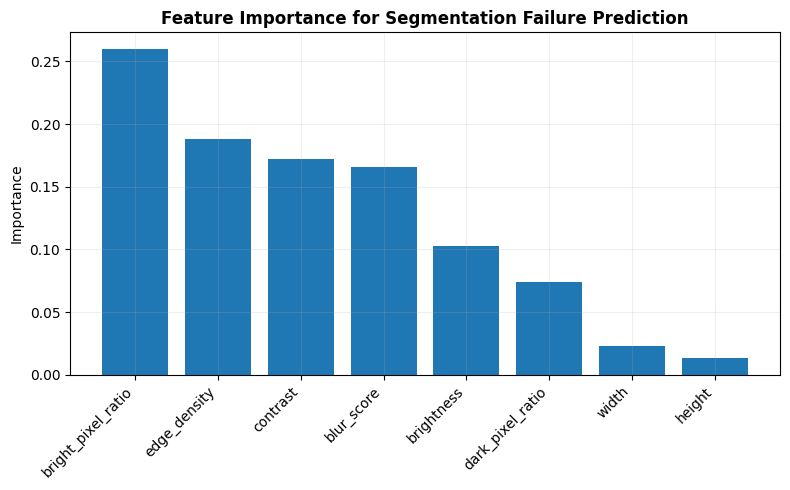

In [72]:
rf = model.named_steps["clf"]

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance_df)

plt.figure(figsize=(8, 5))
plt.bar(feature_importance_df["feature"], feature_importance_df["importance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importance for Segmentation Failure Prediction", weight='bold')
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()

Segmentation failure is primarily driven by visual quality degradation, especially glare and loss of structure, confirming previous findings

### 13.1 Grouped Feature Importance

We group the individual features into three semantic categories, Glare/Lighting, Structure/Detail, and Image Properties, and sum their importances to understand which category of image degradation most strongly drives pipeline failure.


In [69]:
group_map = {
    "bright_pixel_ratio": "Glare / Lighting",
    "brightness": "Glare / Lighting",
    "dark_pixel_ratio": "Glare / Lighting",
    
    "edge_density": "Structure / Detail",
    "contrast": "Structure / Detail",
    "blur_score": "Structure / Detail",
    
    "height": "Image Properties",
    "width": "Image Properties"}

feature_importance_df["group"] = feature_importance_df["feature"].map(group_map)

grouped = (feature_importance_df.groupby("group")["importance"].sum().reset_index().sort_values("importance", ascending=False))

print(grouped)

                group  importance
2  Structure / Detail    0.526160
0    Glare / Lighting    0.437001
1    Image Properties    0.036839


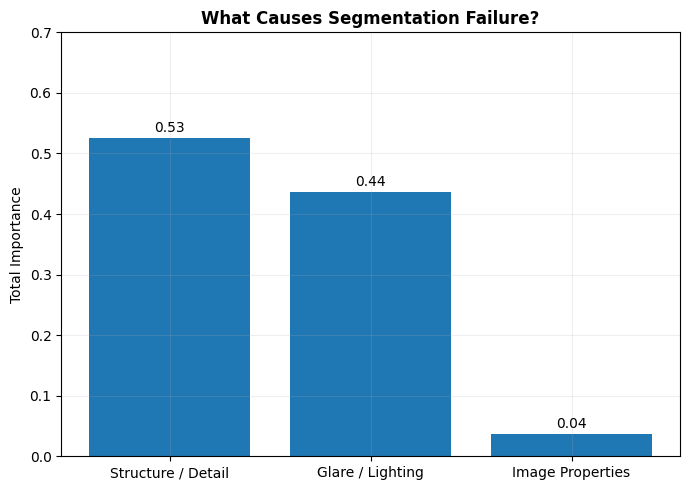

In [71]:
plt.figure(figsize=(7,5))
bars = plt.bar(grouped["group"], grouped["importance"])

for bar, val in zip(bars, grouped["importance"]):
    plt.text(bar.get_x() + bar.get_width()/2,val + 0.01,f"{val:.2f}",ha='center')

plt.ylabel("Total Importance")
plt.title("What Causes Segmentation Failure?", weight='bold')
plt.ylim(0, 0.7)
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()

### Final Takeaways

- After removing improperly formatted inputs, 150 true failures remained in the cleaned dataset.
- Approximately 90% (134/150) were labeled as VectorizationError.
- Inspection of a representative sample suggests that the majority of these cases were caused by upstream segmentation failure, the pipeline returned no valid eye centers or iris boundaries before vectorization was ever reached.
- A preprocessing fallback system was tested on a 50-image sample of these failures and recovered approximately 68% (34/50), suggesting that many failures may be attributable to correctable image quality issues rather than fundamental pipeline limitations.


**Note: All findings are based on sampled subsets of the full dataset. Results should be treated as preliminary and directional until validated across the complete CASIA and IITD image sets.**

**Notebook Interpretation:**

- Image quality issues such as glare and low contrast appear to be a significant driver of pipeline failures, and are often correctable through targeted preprocessing (e.g., CLAHE, glare masking).
- A subset of failures (about 32% in this sample) remained unresolved after all preprocessing variants were attempted, which may indicate limitations in the underlying segmentation model rather than image quality alone.
- These findings are consistent with the broader project direction of exploring adaptive preprocessing as a path to improving pipeline robustness.

**System Improvements Explored:**

- A segmentation failure detector (ROC AUC = 0.85–0.90 on the sample) was developed to identify high-risk inputs before running the full pipeline.
- A preprocessing fallback pipeline was implemented that attempts multiple segmentation-friendly transformations in sequence and accepts the first result that yields valid segmentation outputs.
- These two components were integrated into a lightweight adaptive screening workflow.

### Future Directions
**1. Full Dataset Evaluation**

- Apply the recovery system to the entire CASIA and IITD datasets to validate all preliminary findings at scale.
- Measure overall pipeline success improvement and computational efficiency gains across the full image sets.

**2. Confidence-Based Pipeline Control**

- Use segmentation outputs (e.g., eye center confidence, occlusion scores) to gate progression to vectorization and trigger fallback strategies earlier in the pipeline.
- This builds directly on the current adaptive screening workflow with minimal additional implementation effort.

**3. Expand Failure Detection Model**

- Improve recall of the segmentation failure detector by incorporating additional features such as texture descriptors and spatial iris features.
- Explore lightweight CNN-based predictors as an alternative to the Random Forest classifier for better generalization across image conditions.

**4. Advanced Preprocessing Strategies**

- Dynamically select preprocessing variants based on predicted failure type rather than the current fixed heuristic approach.
- Explore deep learning-based reflection removal and adaptive contrast enhancement for failure modes that current preprocessing cannot resolve.

**5. Improve Segmentation Model Robustness**

- Train or fine-tune the underlying segmentation model on images with glasses, glare, and occluded eyes (eyelashes, eyelids) to address the ~32% of failures that preprocessing alone could not recover.
- Incorporate more diverse real-world imaging conditions into training data to improve generalization.